# 第12回：制約付き最適化（Constrained Optimization）

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rsimd/NITIC-ConbinatorialOptimization/blob/master/lecture12_constraints_optuna.ipynb)

```{note}
:class: dropdown
:open: true
このページは **Jupyter Notebook（.ipynb）** として管理している．対話的に実行する場合は，Jupyter / VS Code / Cursor / Colab で本ファイルを開き，各コードセルを順に実行すればよい．
```

第11回では，「コストを小さくしたいが，性能は大きくしたい」のような **多目的最適化** を Optuna で扱った．第12回では，さらに現実の問題で必ず出てくる **制約** を扱う．

たとえば，次のような条件である．

- 予算は 10 万円以内にする．
- 総重量は 20 kg 以下にする．
- 1 日あたりの作業時間は 8 時間以内にする．
- 配送ルートでは，指定された訪問先をすべて回る．

この回では，Optuna を主役にして，制約を破った候補をどう評価し，どう探索に反映するかを実装する．


## 0. このページで学ぶこと

このページの到達目標は次の 5 つである．

1. 制約付き最適化を，目的関数と制約関数の形で書ける．
2. 「致死ルール」「ペナルティ関数法」「Optuna の `constraints_func`」の違いを説明できる．
3. Optuna の trial に目的値・コスト・重量・制約違反量を記録できる．
4. 実行可能解（feasible solution）だけを抽出し，その中の最良解を選べる．
5. PBL の題材に対して，探索変数・目的関数・制約関数を設計できる．

第11回と同じく，この回でもアルゴリズムの内部実装を細かく作るより，**Optuna に問題をどう渡すか** を重視する．


(sec:constraints-problem)=

## 1. 制約付き最適化の形

制約なしの最小化問題は，たとえば

$$
\min_{\boldsymbol{x}\in\mathcal{X}} f(\boldsymbol{x})
$$

と書ける．ここで $\boldsymbol{x}$ は候補解，$f(\boldsymbol{x})$ は目的関数である．

制約付き最適化では，目的関数を良くするだけでは不十分である．候補解は，決められたルールも守らなければならない．代表的には，

$$
\begin{aligned}
\min_{\boldsymbol{x}\in\mathcal{X}} \quad & f(\boldsymbol{x}) \\
\text{subject to}\quad & g_1(\boldsymbol{x}) \le 0, \\
& g_2(\boldsymbol{x}) \le 0, \\
& \cdots \\
& g_m(\boldsymbol{x}) \le 0
\end{aligned}
$$

のように書く．$g_j(\boldsymbol{x})\le 0$ が制約である．

この書き方では，$g_j(\boldsymbol{x})$ が **0 以下なら制約を満たす**．正なら，その分だけ制約を破っていると考える．Optuna の `constraints_func` もこの約束に従う．


### 1.1 今回のミニ題材：軽くて高性能な装置設計

2 つの連続変数で装置の設計を表す．

- $x_1$：部品 A のグレード
- $x_2$：部品 B のグレード

グレードを上げると性能は上がりやすいが，コストと重量も増えるとする．今回は，次の制約を課す．

$$
\begin{aligned}
\text{cost}(x_1,x_2) &\le 12,\\
\text{weight}(x_1,x_2) &\le 10.
\end{aligned}
$$

目的は，この 2 つの制約を守りながら，性能 $\text{performance}(x_1,x_2)$ を最大化することである．


In [1]:
from __future__ import annotations

import math
import warnings
from typing import Any

import matplotlib.pyplot as plt
import matplotlib_fontja
import numpy as np

warnings.filterwarnings("ignore", message="IProgress not found.*")
import optuna
from jaxtyping import Bool, Float
from optuna.trial import FrozenTrial, TrialState

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)

RANDOM_SEED = 42


次のセルで，性能・コスト・重量を計算する関数を定義する．授業用の人工的な関数なので，値そのものに深い意味はない．大事なのは，**目的関数と制約関数を分けて定義する** ことである．


In [2]:
COST_LIMIT = 12.0
WEIGHT_LIMIT = 10.0


def performance(x1: float, x2: float) -> float:
    """Compute the performance score of a candidate design.

    Args:
        x1: Grade of component A.
        x2: Grade of component B.

    Returns:
        Performance score. Larger is better.
    """
    main_peak = 9.0 * math.exp(-0.35 * ((x1 - 3.4) ** 2 + (x2 - 2.3) ** 2))
    secondary_peak = 5.0 * math.exp(-0.55 * ((x1 - 1.5) ** 2 + (x2 - 4.0) ** 2))
    interaction = 0.8 * math.sin(1.8 * x1) * math.cos(1.2 * x2)
    trend = 0.30 * x1 + 0.22 * x2
    return main_peak + secondary_peak + interaction + trend


def design_cost(x1: float, x2: float) -> float:
    """Compute the cost of a candidate design."""
    return 2.2 * x1 + 1.7 * x2 + 0.25 * x1 * x2


def design_weight(x1: float, x2: float) -> float:
    """Compute the weight of a candidate design."""
    return 1.1 * x1 + 2.0 * x2 + 0.15 * x2**2


def constraint_values(x1: float, x2: float) -> tuple[float, float]:
    """Return constraint values in the form g(x) <= 0.

    Args:
        x1: Grade of component A.
        x2: Grade of component B.

    Returns:
        Pair of constraint values. Positive values mean violations.
    """
    cost_violation = design_cost(x1, x2) - COST_LIMIT
    weight_violation = design_weight(x1, x2) - WEIGHT_LIMIT
    return cost_violation, weight_violation


def total_violation(constraints: tuple[float, ...]) -> float:
    """Return the total positive constraint violation."""
    return sum(max(0.0, value) for value in constraints)


def is_feasible_constraints(constraints: tuple[float, ...]) -> bool:
    """Return whether all constraints are satisfied."""
    return all(value <= 0.0 for value in constraints)


def is_feasible_design(x1: float, x2: float) -> bool:
    """Return whether a candidate design is feasible."""
    return is_feasible_constraints(constraint_values(x1, x2))


制約値の符号を手で確認しておく．`constraints` の各要素が 0 以下なら実行可能であり，正なら制約違反である．


In [3]:
for x1, x2 in [(2.0, 2.0), (3.4, 2.3), (1.2, 4.1), (4.3, 3.2)]:
    constraints = constraint_values(x1, x2)
    print(
        f"x=({x1:.1f}, {x2:.1f}) "
        f"performance={performance(x1, x2):6.3f} "
        f"cost={design_cost(x1, x2):5.2f} "
        f"weight={design_weight(x1, x2):5.2f} "
        f"constraints=({constraints[0]:5.2f}, {constraints[1]:5.2f}) "
        f"feasible={is_feasible_constraints(constraints)}"
    )


x=(2.0, 2.0) performance= 6.176 cost= 8.80 weight= 6.80 constraints=(-3.20, -3.20) feasible=True
x=(3.4, 2.3) performance=10.787 cost=13.35 weight= 9.13 constraints=( 1.35, -0.87) feasible=False
x=(1.2, 4.1) performance= 6.664 cost=10.84 weight=12.04 constraints=(-1.16,  2.04) feasible=False
x=(4.3, 3.2) performance= 6.537 cost=18.34 weight=12.67 constraints=( 6.34,  2.67) feasible=False


## 2. 制約領域を図で見る

制約付き最適化では，「性能が高い点」と「許される点」が一致するとは限らない．探索を始める前に，制約領域を図で見ると考えやすい．

次の図では，背景が性能スコア，白い破線がコスト制約，黒い破線が重量制約である．両方の制約を満たす領域が実行可能領域である．


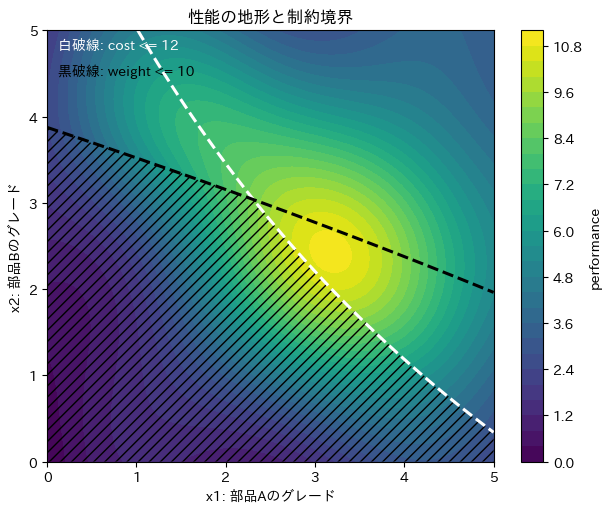

In [4]:
def make_landscape_grid(n_grid: int = 151) -> tuple[
    Float[np.ndarray, "n_grid n_grid"],
    Float[np.ndarray, "n_grid n_grid"],
    Float[np.ndarray, "n_grid n_grid"],
    Float[np.ndarray, "n_grid n_grid"],
    Float[np.ndarray, "n_grid n_grid"],
    Bool[np.ndarray, "n_grid n_grid"],
]:
    """Create grid arrays for plotting the design problem."""
    grid = np.linspace(0.0, 5.0, n_grid)
    x1_grid, x2_grid = np.meshgrid(grid, grid)
    perf_grid = np.vectorize(performance)(x1_grid, x2_grid)
    cost_grid = np.vectorize(design_cost)(x1_grid, x2_grid)
    weight_grid = np.vectorize(design_weight)(x1_grid, x2_grid)
    feasible_grid = (cost_grid <= COST_LIMIT) & (weight_grid <= WEIGHT_LIMIT)
    return x1_grid, x2_grid, perf_grid, cost_grid, weight_grid, feasible_grid


X1, X2, PERF, COST, WEIGHT, FEASIBLE = make_landscape_grid()

fig, ax = plt.subplots(figsize=(7.2, 5.6))
contour = ax.contourf(X1, X2, PERF, levels=32, cmap="viridis")
plt.colorbar(contour, ax=ax, label="performance")
ax.contour(X1, X2, COST, levels=[COST_LIMIT], colors="white", linestyles="--", linewidths=2.2)
ax.contour(X1, X2, WEIGHT, levels=[WEIGHT_LIMIT], colors="black", linestyles="--", linewidths=2.2)
ax.contourf(X1, X2, FEASIBLE, levels=[0.5, 1.5], colors=["none"], hatches=["///"], alpha=0.0)
ax.set_xlabel("x1: 部品Aのグレード")
ax.set_ylabel("x2: 部品Bのグレード")
ax.set_title("性能の地形と制約境界")
ax.text(0.12, 4.78, "白破線: cost <= 12", color="white", weight="bold")
ax.text(0.12, 4.48, "黒破線: weight <= 10", color="black", weight="bold")
plt.show()


以降の比較では，Optuna の各 trial から値を取り出して表や図にする．先に補助関数を定義しておく．


In [5]:
def store_design_attrs(trial: optuna.Trial, x1: float, x2: float) -> tuple[float, float]:
    """Store objective-related values in a trial and return constraints."""
    constraints = constraint_values(x1, x2)
    trial.set_user_attr("x1", x1)
    trial.set_user_attr("x2", x2)
    trial.set_user_attr("performance", performance(x1, x2))
    trial.set_user_attr("cost", design_cost(x1, x2))
    trial.set_user_attr("weight", design_weight(x1, x2))
    trial.set_user_attr("constraints", constraints)
    trial.set_user_attr("total_violation", total_violation(constraints))
    trial.set_user_attr("feasible", is_feasible_constraints(constraints))
    return constraints


def trial_record(trial: FrozenTrial) -> dict[str, Any]:
    """Convert a completed trial to a plain dictionary."""
    x1 = float(trial.params["x1"])
    x2 = float(trial.params["x2"])
    constraints = tuple(float(v) for v in trial.user_attrs.get("constraints", constraint_values(x1, x2)))
    return {
        "number": trial.number,
        "x1": x1,
        "x2": x2,
        "value": trial.value,
        "performance": float(trial.user_attrs.get("performance", performance(x1, x2))),
        "cost": float(trial.user_attrs.get("cost", design_cost(x1, x2))),
        "weight": float(trial.user_attrs.get("weight", design_weight(x1, x2))),
        "constraints": constraints,
        "violation": total_violation(constraints),
        "feasible": is_feasible_constraints(constraints),
    }


def completed_records(study: optuna.Study) -> list[dict[str, Any]]:
    """Return records for completed trials that have both design parameters."""
    records = []
    for trial in study.trials:
        if trial.state != TrialState.COMPLETE:
            continue
        if "x1" not in trial.params or "x2" not in trial.params:
            continue
        records.append(trial_record(trial))
    return records


def best_feasible_record(study: optuna.Study) -> dict[str, Any] | None:
    """Return the best feasible record by true performance."""
    feasible_records = [record for record in completed_records(study) if record["feasible"]]
    if not feasible_records:
        return None
    return max(feasible_records, key=lambda record: float(record["performance"]))


def print_study_summary(name: str, study: optuna.Study) -> None:
    """Print a compact summary of a constrained design study."""
    records = completed_records(study)
    feasible_count = sum(1 for record in records if record["feasible"])
    best = best_feasible_record(study)
    print(f"{name}")
    print(f"  completed trials: {len(records)}")
    print(f"  feasible trials : {feasible_count}")
    if best is None:
        print("  best feasible  : none")
        return
    print(
        f"  best feasible  : trial #{best['number']} "
        f"performance={best['performance']:.3f}, "
        f"x=({best['x1']:.3f}, {best['x2']:.3f}), "
        f"cost={best['cost']:.2f}, weight={best['weight']:.2f}"
    )


## 3. 方法1：致死ルールとして扱う

最も単純な方法は，制約を破った候補に極端に悪い値を返すことである．GA の文脈では，このような扱いを **致死遺伝子** と説明することがある．Optuna でも，実行不可能な trial に非常に低いスコアを返せば，探索から避けられやすくなる．

ただし，この方法には弱点がある．制約を少しだけ破った候補と大きく破った候補を同じように悪く扱うため，境界付近の情報を使いにくい．


In [6]:
def hard_rejection_objective(trial: optuna.Trial) -> float:
    """Return a very bad score when a candidate violates constraints."""
    x1 = trial.suggest_float("x1", 0.0, 5.0)
    x2 = trial.suggest_float("x2", 0.0, 5.0)
    constraints = store_design_attrs(trial, x1, x2)
    if not is_feasible_constraints(constraints):
        return -1_000_000.0
    return performance(x1, x2)


hard_rejection_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
)
hard_rejection_study.optimize(hard_rejection_objective, n_trials=90)
print_study_summary("hard rejection", hard_rejection_study)


hard rejection
  completed trials: 90
  feasible trials : 52
  best feasible  : trial #80 performance=10.598, x=(3.064, 2.126), cost=11.98, weight=8.30


## 4. 方法2：ペナルティ関数法

ペナルティ関数法は，制約違反量を目的関数に混ぜる方法である．今回は性能を最大化したいので，制約違反があるほどスコアを下げる．

$$
F(\boldsymbol{x})
= \text{performance}(\boldsymbol{x})
- \lambda \sum_{j=1}^{m}\max(0,g_j(\boldsymbol{x}))^2
$$

ここで $\lambda$ はペナルティ係数である．制約を満たす点では $\max(0,g_j)=0$ なので，元の性能スコアと同じになる．制約を破る点では，違反量に応じて評価値が悪くなる．

この方法は実装しやすい．一方で，$\lambda$ を小さくしすぎると制約違反を許しやすく，大きくしすぎると探索が硬くなりすぎる．


In [7]:
def penalty_objective(trial: optuna.Trial, penalty_weight: float) -> float:
    """Optimize performance minus a quadratic penalty."""
    x1 = trial.suggest_float("x1", 0.0, 5.0)
    x2 = trial.suggest_float("x2", 0.0, 5.0)
    constraints = store_design_attrs(trial, x1, x2)
    penalty = penalty_weight * sum(max(0.0, value) ** 2 for value in constraints)
    return performance(x1, x2) - penalty


def run_penalty_study(penalty_weight: float, n_trials: int = 90) -> optuna.Study:
    """Run an Optuna study with a fixed penalty weight."""
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    )
    study.optimize(lambda trial: penalty_objective(trial, penalty_weight), n_trials=n_trials)
    return study


penalty_studies = {weight: run_penalty_study(weight) for weight in [0.5, 5.0, 50.0]}
for weight, study in penalty_studies.items():
    print_study_summary(f"penalty weight = {weight:g}", study)


penalty weight = 0.5
  completed trials: 90
  feasible trials : 35
  best feasible  : trial #86 performance=10.545, x=(2.969, 2.169), cost=11.83, weight=8.31
penalty weight = 5
  completed trials: 90
  feasible trials : 47
  best feasible  : trial #82 performance=10.596, x=(3.063, 2.126), cost=11.98, weight=8.30
penalty weight = 50
  completed trials: 90
  feasible trials : 47
  best feasible  : trial #83 performance=10.502, x=(2.807, 2.393), cost=11.92, weight=8.73


## 5. 方法3：Optuna の `constraints_func` を使う

Optuna では，一部の sampler に `constraints_func` を渡せる．`constraints_func` は，完了した trial を受け取り，制約値の列を返す関数である．

約束は次の通りである．

- 返り値の各要素が **0 以下** なら，その制約は満たされている．
- 返り値のどれかが **正** なら，その trial は制約を破っている．
- 複数制約がある場合は，すべて 0 以下の trial だけが実行可能である．

ここでは `TPESampler(constraints_func=...)` を使う．目的関数は性能だけを返し，制約値は `trial.set_user_attr` で保存してから `constraints_func` で返す．この **目的関数と制約関数の分離** が今回の中心である．


In [8]:
def optuna_objective(trial: optuna.Trial) -> float:
    """Return only the true performance score."""
    x1 = trial.suggest_float("x1", 0.0, 5.0)
    x2 = trial.suggest_float("x2", 0.0, 5.0)
    store_design_attrs(trial, x1, x2)
    return performance(x1, x2)


def optuna_constraints(trial: FrozenTrial) -> tuple[float, float]:
    """Return constraints stored in a completed trial.

    Optuna treats positive values as constraint violations.
    """
    return tuple(float(value) for value in trial.user_attrs["constraints"])


constrained_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(
        constraints_func=optuna_constraints,
        seed=RANDOM_SEED,
    ),
)
constrained_study.optimize(optuna_objective, n_trials=90)
print_study_summary("TPESampler + constraints_func", constrained_study)


TPESampler + constraints_func
  completed trials: 90
  feasible trials : 52
  best feasible  : trial #80 performance=10.598, x=(3.064, 2.126), cost=11.98, weight=8.30


```{hint} `best_trial` と実行可能解
:class: dropdown

制約付き最適化では，Optuna の `best_trial` は実行可能 trial から選ばれる．ただし授業や PBL では，「どの trial が実行可能か」「制約違反量はいくらか」を自分で表に出した方が説明しやすい．このノートでは `best_feasible_record` を用意し，実行可能 trial だけを明示的に抽出している．
```

次に，各方法の結果を同じ表で比較する．


In [9]:
studies: list[tuple[str, optuna.Study]] = [("hard rejection", hard_rejection_study)]
studies.extend((f"penalty {weight:g}", study) for weight, study in penalty_studies.items())
studies.append(("constraints_func", constrained_study))

print("method              feasible/trials    performance    x1      x2      cost    weight")
print("-" * 84)
for name, study in studies:
    records = completed_records(study)
    feasible_count = sum(1 for record in records if record["feasible"])
    best = best_feasible_record(study)
    if best is None:
        print(f"{name:<19} {feasible_count:>3}/{len(records):<3}          none")
        continue
    print(
        f"{name:<19} {feasible_count:>3}/{len(records):<3} "
        f"{best['performance']:>14.3f} "
        f"{best['x1']:>7.3f} {best['x2']:>7.3f} "
        f"{best['cost']:>7.2f} {best['weight']:>8.2f}"
    )


method              feasible/trials    performance    x1      x2      cost    weight
------------------------------------------------------------------------------------
hard rejection       52/90          10.598   3.064   2.126   11.98     8.30
penalty 0.5          35/90          10.545   2.969   2.169   11.83     8.31
penalty 5            47/90          10.596   3.063   2.126   11.98     8.30
penalty 50           47/90          10.502   2.807   2.393   11.92     8.73
constraints_func     52/90          10.598   3.064   2.126   11.98     8.30


## 6. 探索結果を可視化する

表だけでは，探索がどこを調べたかが分かりにくい．次の図では，赤い点を制約違反 trial，白い点を実行可能 trial，星印を実行可能 trial の中の最良点として表示する．

制約付き最適化では，最終的な 1 点だけでなく，「どの領域を調べ，どの候補が制約で落ちたか」も発表資料に入れるとよい．


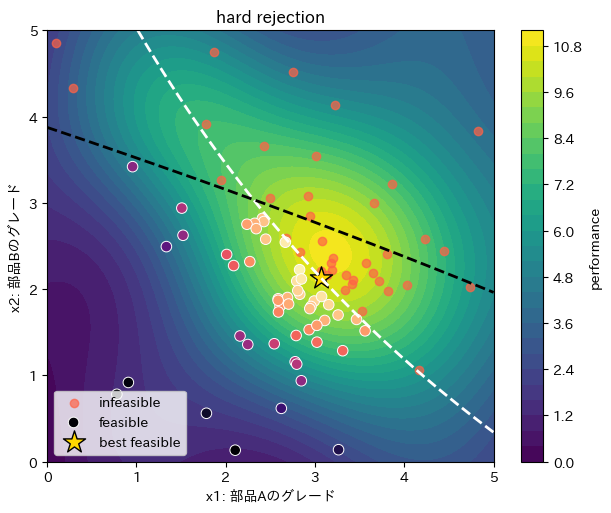

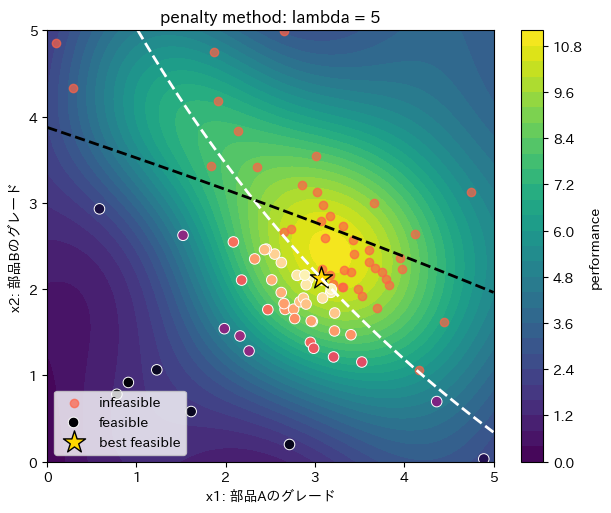

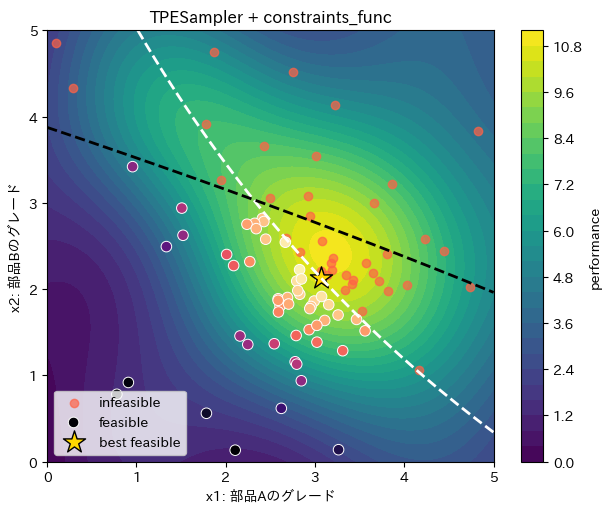

In [10]:
def plot_study_trials(study: optuna.Study, title: str) -> None:
    """Plot completed trials on the design landscape."""
    records = completed_records(study)
    xs = np.array([record["x1"] for record in records], dtype=float)
    ys = np.array([record["x2"] for record in records], dtype=float)
    feasible = np.array([record["feasible"] for record in records], dtype=bool)
    scores = np.array([record["performance"] for record in records], dtype=float)

    fig, ax = plt.subplots(figsize=(7.2, 5.6))
    contour = ax.contourf(X1, X2, PERF, levels=32, cmap="viridis")
    plt.colorbar(contour, ax=ax, label="performance")
    ax.contour(X1, X2, COST, levels=[COST_LIMIT], colors="white", linestyles="--", linewidths=2.0)
    ax.contour(X1, X2, WEIGHT, levels=[WEIGHT_LIMIT], colors="black", linestyles="--", linewidths=2.0)

    ax.scatter(xs[~feasible], ys[~feasible], c="tomato", s=36, alpha=0.70, label="infeasible")
    ax.scatter(
        xs[feasible],
        ys[feasible],
        c=scores[feasible],
        cmap="magma",
        edgecolor="white",
        linewidth=0.7,
        s=58,
        label="feasible",
    )

    best = best_feasible_record(study)
    if best is not None:
        ax.scatter(
            [best["x1"]],
            [best["x2"]],
            marker="*",
            s=280,
            c="gold",
            edgecolor="black",
            linewidth=1.0,
            label="best feasible",
        )

    ax.set_xlabel("x1: 部品Aのグレード")
    ax.set_ylabel("x2: 部品Bのグレード")
    ax.set_title(title)
    ax.legend(loc="lower left")
    plt.show()


plot_study_trials(hard_rejection_study, "hard rejection")
plot_study_trials(penalty_studies[5.0], "penalty method: lambda = 5")
plot_study_trials(constrained_study, "TPESampler + constraints_func")


## 7. どの方法を使うべきか

今回の 3 つの方法を整理する．

| 方法 | 実装のしやすさ | 長所 | 注意点 |
|---|---:|---|---|
| 致死ルール | 高い | 制約を絶対に破らせたくない，という意図が明確 | 境界付近の情報を捨てやすい |
| ペナルティ関数法 | 高い | 任意の sampler で使いやすい | ペナルティ係数 $\lambda$ の調整が必要 |
| `constraints_func` | 中程度 | 目的関数と制約を分けて書ける | 対応 sampler と Optuna の仕様を確認する必要がある |

PBL では，まず `constraints_func` を第一候補にするとよい．理由は，評価したいものと守るべきルールが分かれており，発表で説明しやすいからである．一方，制約が複雑すぎる場合や sampler が対応していない場合は，ペナルティ関数法も実用的である．


## 8. PBL へつなげる：整数変数の制約付き Optuna

PBL では，連続値だけでなく，人数・個数・カード枚数・担当数のような整数変数もよく出てくる．Optuna では `suggest_int` を使えば整数変数を扱える．

例として，イベント運営の人員配置を考える．受付・誘導・撮影の人数を決め，イベント品質を最大化する．ただし，予算と総人数の制約がある．


In [11]:
ROLE_COST = {"reception": 1.2, "guide": 1.0, "photo": 1.8}
EVENT_BUDGET_LIMIT = 11.0
STAFF_LIMIT = 9


def event_quality(reception: int, guide: int, photo: int) -> float:
    """Compute the quality score of an event staff assignment."""
    coverage = 3.0 * math.log1p(reception) + 2.5 * math.log1p(guide) + 2.8 * math.log1p(photo)
    balance_bonus = 1.2 / (1.0 + abs(reception - guide))
    photo_shortage_penalty = 1.5 if photo < 2 else 0.0
    return coverage + balance_bonus - photo_shortage_penalty


def event_cost(reception: int, guide: int, photo: int) -> float:
    """Compute the staffing cost."""
    return (
        ROLE_COST["reception"] * reception
        + ROLE_COST["guide"] * guide
        + ROLE_COST["photo"] * photo
    )


def event_constraints_from_params(reception: int, guide: int, photo: int) -> tuple[float, float, float]:
    """Return event constraints in the form g(x) <= 0."""
    total_staff = reception + guide + photo
    return (
        event_cost(reception, guide, photo) - EVENT_BUDGET_LIMIT,
        total_staff - STAFF_LIMIT,
        1 - reception,  # 受付は最低1人必要である．
    )


def event_objective(trial: optuna.Trial) -> float:
    """Optimize event quality under staffing constraints."""
    reception = trial.suggest_int("reception", 0, 8)
    guide = trial.suggest_int("guide", 0, 8)
    photo = trial.suggest_int("photo", 0, 5)
    constraints = event_constraints_from_params(reception, guide, photo)
    trial.set_user_attr("constraints", constraints)
    trial.set_user_attr("cost", event_cost(reception, guide, photo))
    trial.set_user_attr("staff", reception + guide + photo)
    trial.set_user_attr("quality", event_quality(reception, guide, photo))
    return event_quality(reception, guide, photo)


def event_constraints(trial: FrozenTrial) -> tuple[float, float, float]:
    """Return event constraints stored in a completed trial."""
    return tuple(float(value) for value in trial.user_attrs["constraints"])


event_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(constraints_func=event_constraints, seed=RANDOM_SEED),
)
event_study.optimize(event_objective, n_trials=100)

best_event_trial = event_study.best_trial
print("最良の人員配置")
print(best_event_trial.params)
print(f"quality={best_event_trial.value:.3f}")
print(f"cost={best_event_trial.user_attrs['cost']:.2f} / limit={EVENT_BUDGET_LIMIT}")
print(f"staff={best_event_trial.user_attrs['staff']} / limit={STAFF_LIMIT}")
print(f"constraints={best_event_trial.user_attrs['constraints']}")


最良の人員配置
{'reception': 3, 'guide': 3, 'photo': 2}
quality=11.901
cost=10.20 / limit=11.0
staff=8 / limit=9
constraints=(-0.8000000000000007, -1, -2)


## 9. PBL の問題設定テンプレート

自分たちの PBL 題材では，いきなりコードを書かず，次の 4 点を先に決めるとよい．

| 項目 | 書くこと | Optuna での対応 |
|---|---|---|
| 探索変数 | 何を変えられるか | `trial.suggest_float`, `trial.suggest_int`, `trial.suggest_categorical` |
| 目的関数 | 何を最大化または最小化するか | objective の返り値 |
| 制約関数 | 何を守る必要があるか | `constraints_func` の返り値 |
| 可視化 | 結果をどう説明するか | 散布図，表，制約違反数，採用案の注釈 |

第13回以降は，この表を埋めるところから始める．題材が配送ルートなら「距離」「時間」「車両数」，デッキ編成なら「勝率」「総コスト」「役割枚数」，シフト作成なら「公平性」「勤務時間」「必要人数」が候補になる．


## 10. 演習

### 演習1：制約値を手で確認する

次の候補について，コスト制約と重量制約を満たすかを確認せよ．

1. $(x_1,x_2)=(2.5,2.0)$
2. $(x_1,x_2)=(4.0,2.5)$
3. $(x_1,x_2)=(1.0,4.0)$

`constraint_values` の返り値が 0 以下かどうかを見ること．

### 演習2：制約を厳しくする

`COST_LIMIT` を 10，`WEIGHT_LIMIT` を 8 に変更して，`constraints_func` の結果がどう変わるか確認せよ．実行可能 trial の数と最良性能はどう変わるだろうか．

### 演習3：ペナルティ係数を変える

ペナルティ法で `penalty_weight` を 0.1，1，10，100 に変え，実行可能 trial の数と最良性能を比較せよ．制約を守りやすい係数はどのあたりだろうか．

### 演習4：PBL 題材へ置き換える

自分たちの PBL 題材について，探索変数を 3 つ以上，制約を 2 つ以上書き出し，`constraints_func` の形で実装せよ．


## 11. まとめ

- 制約付き最適化では，目的関数だけでなく，守るべき条件を制約関数として明示する．
- $g(\boldsymbol{x})\le 0$ の形にすると，制約違反量を扱いやすい．
- 致死ルールは単純だが，制約を少し破った候補と大きく破った候補を区別しにくい．
- ペナルティ関数法は実装しやすいが，ペナルティ係数の調整が必要である．
- Optuna の `constraints_func` を使うと，目的関数と制約を分けて実装できる．
- PBL では，探索空間・目的関数・制約関数・可視化を先に設計すると，実装と発表が作りやすくなる．

次回以降は，ここまでに学んだ GA，PSO，ACO，DE，CMA-ES，BO，Optuna を使って，自分たちの題材を解く段階に入る．


## 参考リンク

- [Optuna 公式サイト](https://optuna.org/)
- [Optuna 公式ドキュメント](https://optuna.readthedocs.io/en/stable/)
- [Optuna API Reference: TPESampler](https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html)
- [Optuna FAQ: constrained multi-objective optimization example](https://optuna.readthedocs.io/en/stable/faq.html#how-can-i-optimize-a-model-with-some-constraints)
